In [51]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [98]:
from arch import arch_model

from sklearn import linear_model
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [54]:
asx200 = pd.read_html('https://en.wikipedia.org/wiki/S%26P/ASX_200')[2]

In [57]:
end_date = '2024-12-31'

start_date = pd.to_datetime(end_date)-pd.DateOffset(365*10)

asx200['Symbol'] = asx200['Code'].str.replace('.', '-').astype(str) + '.ax'
# asx200['Symbol'] = asx200['Code'].str.replace('.', '-')

symbols_list = asx200['Symbol'].unique().tolist()

df = yf.download(tickers=symbols_list,
                 start=start_date,
                 end=end_date).stack()

df.index.names = ['date', 'ticker']

df.columns = df.columns.str.lower()

df = df.drop(columns=['adj close'])

df

[*********************100%***********************]  200 of 200 completed

22 Failed downloads:
['ALU.AX', 'GUD.AX', 'UWL.AX', 'PDL.AX', 'NCM.AX', 'VUK.AX', 'SVW.AX', 'UMG.AX', 'ABC.AX', 'CGC.AX', 'SLR.AX', 'CSR.AX', 'BKL.AX', 'ABP.AX', 'AWC.AX', 'AVZ.AX', 'LNK.AX', 'BLD.AX', 'JHG.AX', 'AKE.AX', 'IVC.AX', 'OZL.AX']: YFTzMissingError('possibly delisted; no timezone found')


Price                   close        high         low        open     volume
date       ticker                                                           
2015-01-05 AGL.AX    8.329430    8.359962    8.188977    8.188977  1038074.0
           AIA.AX    3.456597    3.506936    3.448208    3.473377    23281.0
           ALD.AX   24.249126   24.345298   23.775136   23.871308   435977.0
           ALL.AX    5.673504    5.733768    5.621848    5.639067  1296266.0
           ALQ.AX    3.897570    3.962530    3.875917    3.875917  1117657.0
...                       ...         ...         ...         ...        ...
2024-12-30 WOW.AX   30.102041   30.250084   29.934259   30.161258   659932.0
           WPR.AX    2.390000    2.430000    2.390000    2.410000  1332373.0
           WTC.AX  123.000000  123.000000  120.500000  121.989998   213903.0
           XRO.AX  167.389999  168.100006  165.639999  167.990005   173653.0
           ZIP.AX    3.000000    3.100000    2.950000    3.000000  7740629.0

[426634 rows x 5 columns]

In [66]:
# Compute n-day lag close price within each ticker group
df['min_1_close'] = df.groupby('ticker')['close'].shift(1)
df['min_2_close'] = df.groupby('ticker')['close'].shift(2)
df['min_3_close'] = df.groupby('ticker')['close'].shift(3)
df['min_4_close'] = df.groupby('ticker')['close'].shift(4)

# Compute log returns
df['log_ret'] = np.log(df['close']) - np.log(df['min_1_close'])

df['variance'] = df['log_ret'].rolling(180).var()

df['min_1_trend'] = np.where(df['close'] > df['min_1_close'], 1, -1)
df['min_2_trend'] = np.where(df['min_1_close'] > df['min_2_close'], 1, -1)
df['min_3_trend'] = np.where(df['min_2_close'] > df['min_3_close'], 1, -1)

df['trend_3_day'] = np.where(df['min_1_trend']+df['min_2_trend']+df['min_3_trend'] > 0, 1, -1)

df

Price                   close        high         low        open     volume  \
date       ticker                                                              
2015-01-09 AGL.AX    8.384391    8.390498    8.256152    8.256152  1412903.0   
           AIA.AX    3.406259    3.498547    3.406259    3.498547    63659.0   
           ALD.AX   24.283468   24.345293   23.981214   24.111732   513189.0   
           ALL.AX    5.811252    5.819861    5.716550    5.768206  1426293.0   
           ALQ.AX    3.731562    3.760434    3.652168    3.717127  1464467.0   
...                       ...         ...         ...         ...        ...   
2024-12-30 WOW.AX   30.102041   30.250084   29.934259   30.161258   659932.0   
           WPR.AX    2.390000    2.430000    2.390000    2.410000  1332373.0   
           WTC.AX  123.000000  123.000000  120.500000  121.989998   213903.0   
           XRO.AX  167.389999  168.100006  165.639999  167.990005   173653.0   
           ZIP.AX    3.000000    3.100000    2.950000    3.000000  7740629.0   

Price              min_1_close  min_2_close  min_3_close  min_4_close  \
date       ticker                                                       
2015-01-09 AGL.AX          NaN          NaN          NaN          NaN   
           AIA.AX          NaN          NaN          NaN          NaN   
           ALD.AX          NaN          NaN          NaN          NaN   
           ALL.AX          NaN          NaN          NaN          NaN   
           ALQ.AX          NaN          NaN          NaN          NaN   
...                        ...          ...          ...          ...   
2024-12-30 WOW.AX    30.111912    29.993477    29.973740    29.786217   
           WPR.AX     2.408800     2.418632     2.389136     2.339977   
           WTC.AX   122.040001   124.010002   123.190002   121.330002   
           XRO.AX   168.919998   168.660004   168.169998   166.039993   
           ZIP.AX     3.060000     2.910000     2.960000     2.830000   

Price               log_ret  variance  min_1_trend  min_2_trend  min_3_trend  \
date       ticker                                                              
2015-01-09 AGL.AX       NaN       NaN           -1           -1           -1   
           AIA.AX       NaN       NaN           -1           -1           -1   
           ALD.AX       NaN       NaN           -1           -1           -1   
           ALL.AX       NaN       NaN           -1           -1           -1   
           ALQ.AX       NaN       NaN           -1           -1           -1   
...                     ...       ...          ...          ...          ...   
2024-12-30 WOW.AX -0.000328  0.000445           -1            1            1   
           WPR.AX -0.007835  0.000445           -1           -1            1   
           WTC.AX  0.007835  0.000445            1           -1            1   
           XRO.AX -0.009099  0.000446           -1            1            1   
           ZIP.AX -0.019803  0.000447           -1            1           -1   

Price              trend_3_day  
date       ticker               
2015-01-09 AGL.AX           -1  
           AIA.AX           -1  
           ALD.AX           -1  
           ALL.AX           -1  
           ALQ.AX           -1  
...                        ...  
2024-12-30 WOW.AX            1  
           WPR.AX           -1  
           WTC.AX            1  
           XRO.AX            1  
           ZIP.AX           -1  

[421464 rows x 15 columns]

In [67]:
df.dropna(inplace=True)

<Axes: xlabel='date'>

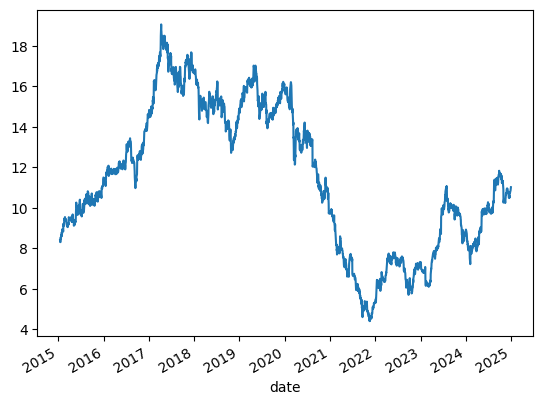

In [68]:
df.xs('AGL.AX', level='ticker')['close'].plot()

In [69]:
start_date = pd.to_datetime('2018-06-01')
end_date = pd.to_datetime('2018-07-31')

# Select a specific ticker (e.g., 'AAPL')
ticker = 'AGL.AX'  # Change this to the ticker you want to plot
df_ticker = df.xs(ticker, level='ticker')  # Extract data for the ticker

# Filter by date range
filtered_df = df_ticker.loc[
    (df_ticker.index.get_level_values('date') >= start_date) &
    (df_ticker.index.get_level_values('date') <= end_date)
]

filtered_df

Price,close,high,low,open,volume,min_1_close,min_2_close,min_3_close,min_4_close,log_ret,variance,min_1_trend,min_2_trend,min_3_trend,trend_3_day
date,,,,,,,,,,,,,,,
2018-06-01,15.297953,15.529633,15.273379,15.501550,1124988.0,15.515591,15.368158,15.297953,15.382199,-0.014126,0.000370,-1,1,1,1
2018-06-04,14.771405,15.101374,14.609930,15.094354,2887076.0,15.297953,15.515591,15.368158,15.297953,-0.035026,0.000362,-1,-1,1,-1
2018-06-05,14.630991,14.792465,14.413352,14.743321,2345233.0,14.771405,15.297953,15.515591,15.368158,-0.009551,0.000333,-1,-1,-1,-1
2018-06-06,14.736301,14.834590,14.630992,14.673116,2156204.0,14.630991,14.771405,15.297953,15.515591,0.007172,0.000322,1,-1,-1,-1
2018-06-07,14.883738,14.911819,14.532706,14.638015,1761886.0,14.736301,14.630991,14.771405,15.297953,0.009955,0.000352,1,1,-1,1
2018-06-08,14.876717,15.031170,14.799489,14.883737,1175872.0,14.883738,14.736301,14.630991,14.771405,-0.000472,0.000355,-1,1,1,1
2018-06-12,14.757363,14.834589,14.602909,14.820549,2352127.0,14.876717,14.883738,14.736301,14.630991,-0.008055,0.000199,-1,-1,1,-1
2018-06-13,15.129456,15.164560,14.729280,14.757363,2556327.0,14.757363,14.876717,14.883738,14.736301,0.024901,0.000370,1,-1,-1,-1
2018-06-14,15.052232,15.136479,14.960963,15.038190,1508829.0,15.129456,14.757363,14.876717,14.883738,-0.005117,0.000524,-1,1,-1,-1


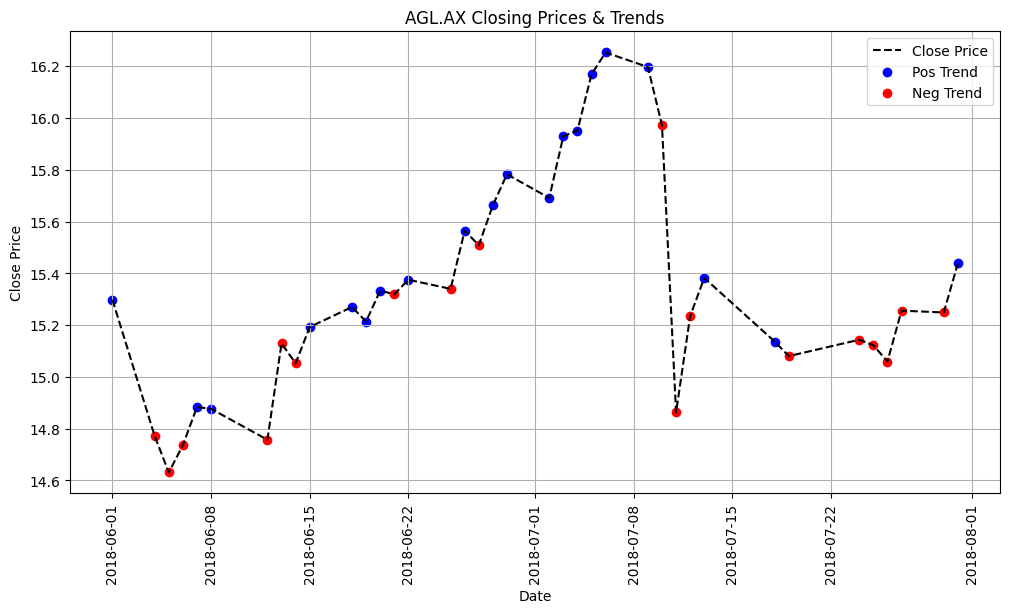

In [70]:
start_date = pd.to_datetime('2018-06-01')
end_date = pd.to_datetime('2018-07-31')

# Select a specific ticker (e.g., 'AAPL')
ticker = 'AGL.AX'  # Change this to the ticker you want to plot
df_ticker = df.xs(ticker, level='ticker')  # Extract data for the ticker

# Filter by date range
filtered_df = df_ticker.loc[
    (df_ticker.index.get_level_values('date') >= start_date) &
    (df_ticker.index.get_level_values('date') <= end_date)
]

# Create the plot
plt.figure(figsize=(12, 6))

# Plot the closing price
plt.plot(
    filtered_df.index, filtered_df['close'], 'k--', label='Close Price'
)

# Scatter plot for positive trend
plt.scatter(
    filtered_df.index[filtered_df['trend_3_day'] == 1],
    filtered_df['close'][filtered_df['trend_3_day'] == 1],
    color='b', label='Pos Trend'
)

# Scatter plot for negative trend
plt.scatter(
    filtered_df.index[filtered_df['trend_3_day'] == -1],
    filtered_df['close'][filtered_df['trend_3_day'] == -1],
    color='r', label='Neg Trend'
)

# Formatting
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title(f"{ticker} Closing Prices & Trends")
plt.legend()
plt.xticks(rotation=90)
plt.grid()

plt.show()

In [91]:
ticker = 'AGL.AX'  # Replace with the ticker you want
train_date = '2022-12-31'

features = ['min_1_close', 'trend_3_day']
target = 'close'

# Filter data for the specific ticker
df_ticker = df.loc[df.index.get_level_values('ticker') == ticker]

# Split the data based on the date
X_train = df_ticker.loc[df_ticker.index.get_level_values('date') <= train_date, features]
X_test = df_ticker.loc[df_ticker.index.get_level_values('date') > train_date, features]

y_train = df_ticker.loc[df_ticker.index.get_level_values('date') <= train_date, target]
y_test = df_ticker.loc[df_ticker.index.get_level_values('date') > train_date, target]

In [94]:
y_train

date        ticker
2015-01-15  AGL.AX    8.402709
2015-01-16  AGL.AX    8.305004
2015-01-19  AGL.AX    8.298895
2015-01-20  AGL.AX    8.384391
2015-01-21  AGL.AX    8.543162
                        ...   
2022-12-22  AGL.AX    7.248908
2022-12-23  AGL.AX    7.275623
2022-12-28  AGL.AX    7.320150
2022-12-29  AGL.AX    7.284529
2022-12-30  AGL.AX    7.186570
Name: close, Length: 1959, dtype: float64

In [93]:
X_test

,Price,min_1_close,trend_3_day
date,ticker,,
2023-01-03,AGL.AX,7.186570,-1
2023-01-04,AGL.AX,7.159854,-1
2023-01-05,AGL.AX,7.302339,-1
2023-01-06,AGL.AX,7.150949,-1
2023-01-09,AGL.AX,6.955033,-1
...,...,...,...
2024-12-20,AGL.AX,10.509999,1
2024-12-23,AGL.AX,10.744860,-1
2024-12-24,AGL.AX,10.744860,1


In [109]:
# Create linear regression object
# regr = linear_model.LinearRegression(fit_intercept=False)
regr = linear_model.LinearRegression(fit_intercept=True)

In [110]:
# Train the model using the training set
regr.fit(X_train, y_train)

LinearRegression()

In [111]:
# Make predictions using the testing set
y_pred = regr.predict(X_test)

In [112]:
# The mean squared error
print('Root Mean Squared Error: {0:.2f}'.format(np.sqrt(mean_squared_error(y_test, y_pred))))

# Explained variance score: 1 is perfect prediction
print('Variance Score: {0:.2f}'.format(r2_score(y_test, y_pred)))

Root Mean Squared Error: 0.13
Variance Score: 0.99


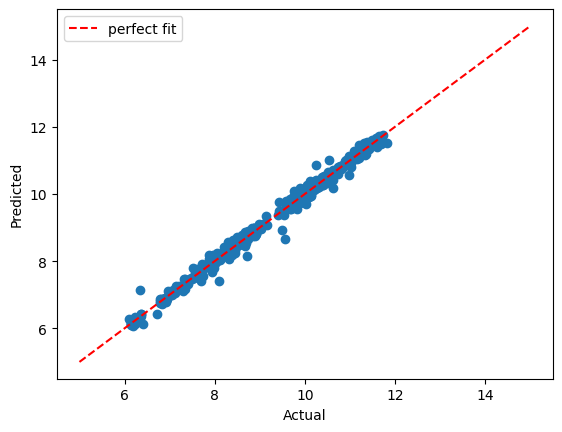

In [113]:
plt.scatter(y_test, y_pred)
plt.plot([5, 15], [5, 15], 'r--', label='perfect fit')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()

In [114]:
print('Root Mean Squared Error: {0:.2f}'.format(np.sqrt(mean_squared_error(y_test, X_test.min_1_close))))

Root Mean Squared Error: 0.14
